In [1]:
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')

from plot_utils import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions
from standardized_plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components,
    plot_3d_graph_components_pu_only as std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

import numpy as np
import networkx as nx


/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/bondmodifier_utils.py:36: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.signal import find_peaks


In [2]:
import glob
file_list = glob.glob('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x*/T*/dump.lammpstrj')

In [3]:
file_list 

['/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1200K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1100K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T800K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1300K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1000K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1250K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T900K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1200K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T800K/dump.lammpstrj',
 '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3

In [4]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy


In [5]:
import ase 

In [6]:
pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow(
    pipeline=pipe,
    # disable_pair=("Na", "Cl"),  # Keep all bonds for construction
    metals=["Pu"],  # Only Pu for cluster analysis, ignoring Na nodes
    anion="Cl",
    rdf_samples=rdf_samples,
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)



Loaded trajectory with 14615 frames
Standardized plotting style configured
Pairwise cutoffs: {('Pu', 'Cl'): 3.2600000000000002, ('Cl', 'Pu'): 3.2600000000000002, ('Na', 'Cl'): 3.42, ('Cl', 'Na'): 3.42}


In [7]:
result["rdf"].keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'complete', 'r'])

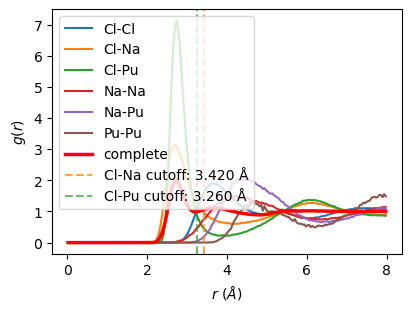

In [8]:
plot_rdfs(result["rdf"], cutoffs=cutoffs)

In [9]:
from bondmodifier_utils import build_shared_anion_graph

In [10]:
# sizes, cluster_ids, G = build_shared_anion_graph(result["data"], result["names"], anion="Cl", metals=["Pu"])

Clusters: 115 | Largest: 37 | Avg: 3.34


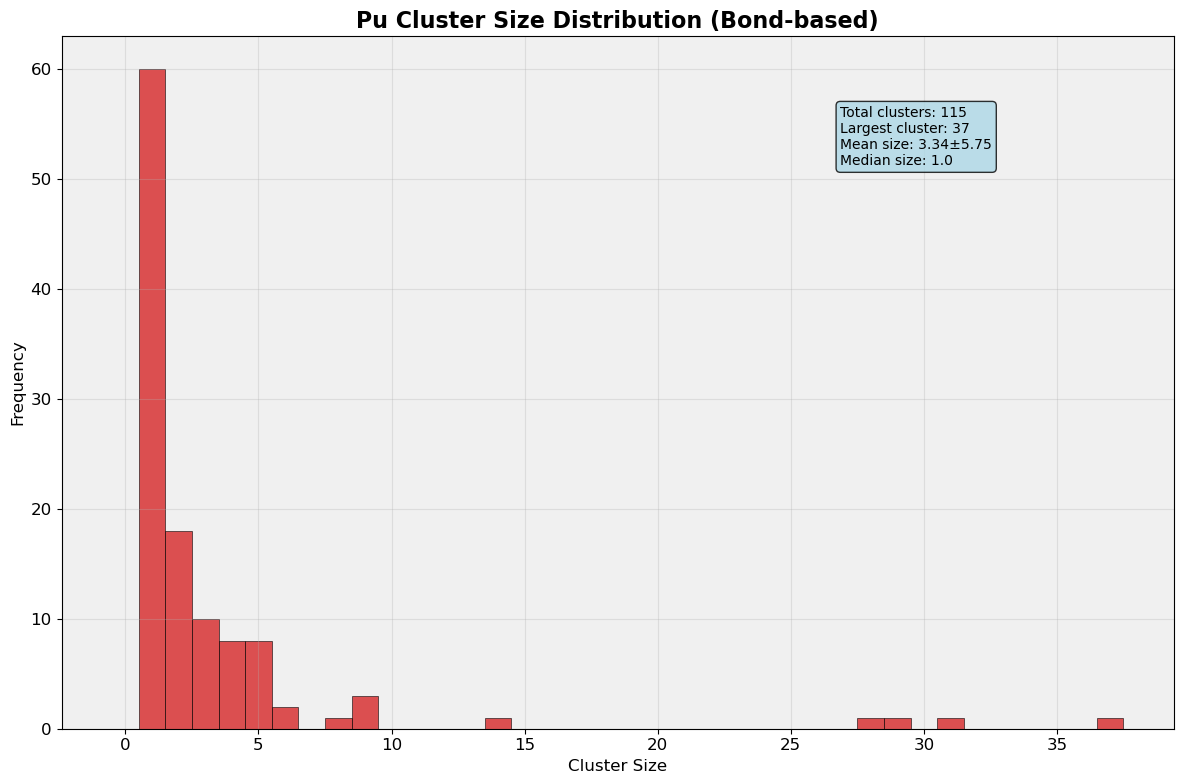

Bond counts: {'Cl-Na': 4398, 'Cl-Pu': 2250}


In [11]:
# Unpack results and analyze using standardized plotting
names = result["names"]
sizes = result["sizes"]
cluster_ids = result["cluster_ids"]
data0 = result["data"]
G = result["graph"]

print(f"Clusters: {len(sizes)} | Largest: {np.max(sizes) if len(sizes)>0 else 0} | Avg: {np.mean(sizes) if len(sizes)>0 else 0:.2f}")

# Plot standardized cluster size distribution
std_plot_cluster_size_distribution(sizes, title="Pu Cluster Size Distribution (Bond-based)")

# Bond summary
counts = summarize_bonds(data0, names)
print("Bond counts:", counts)



In [12]:
result["sizes"]


array([28,  5,  6,  1,  6,  2,  1,  2,  5,  1, 14,  1,  4,  4,  1,  5,  1,
        2,  4,  1,  1,  9, 37,  1,  1,  5,  9,  1,  1,  1,  1,  1,  1,  1,
        1,  4,  4,  1,  1,  1,  5,  2,  1,  2,  3,  1,  3,  1,  4, 29,  2,
        1,  8,  2,  5, 31,  2,  2,  2,  1,  1,  1,  1,  3,  5,  2,  4,  1,
        3,  3,  1,  1,  1,  1,  3,  3,  2,  4,  2,  1,  2,  9,  1,  1,  1,
        1,  1,  2,  2,  3,  1,  2,  1,  1,  3,  1,  1,  1,  5,  2,  1,  1,
        1,  3,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1])

In [13]:
from plot_utils import plot_3d_graph_components_pu_only

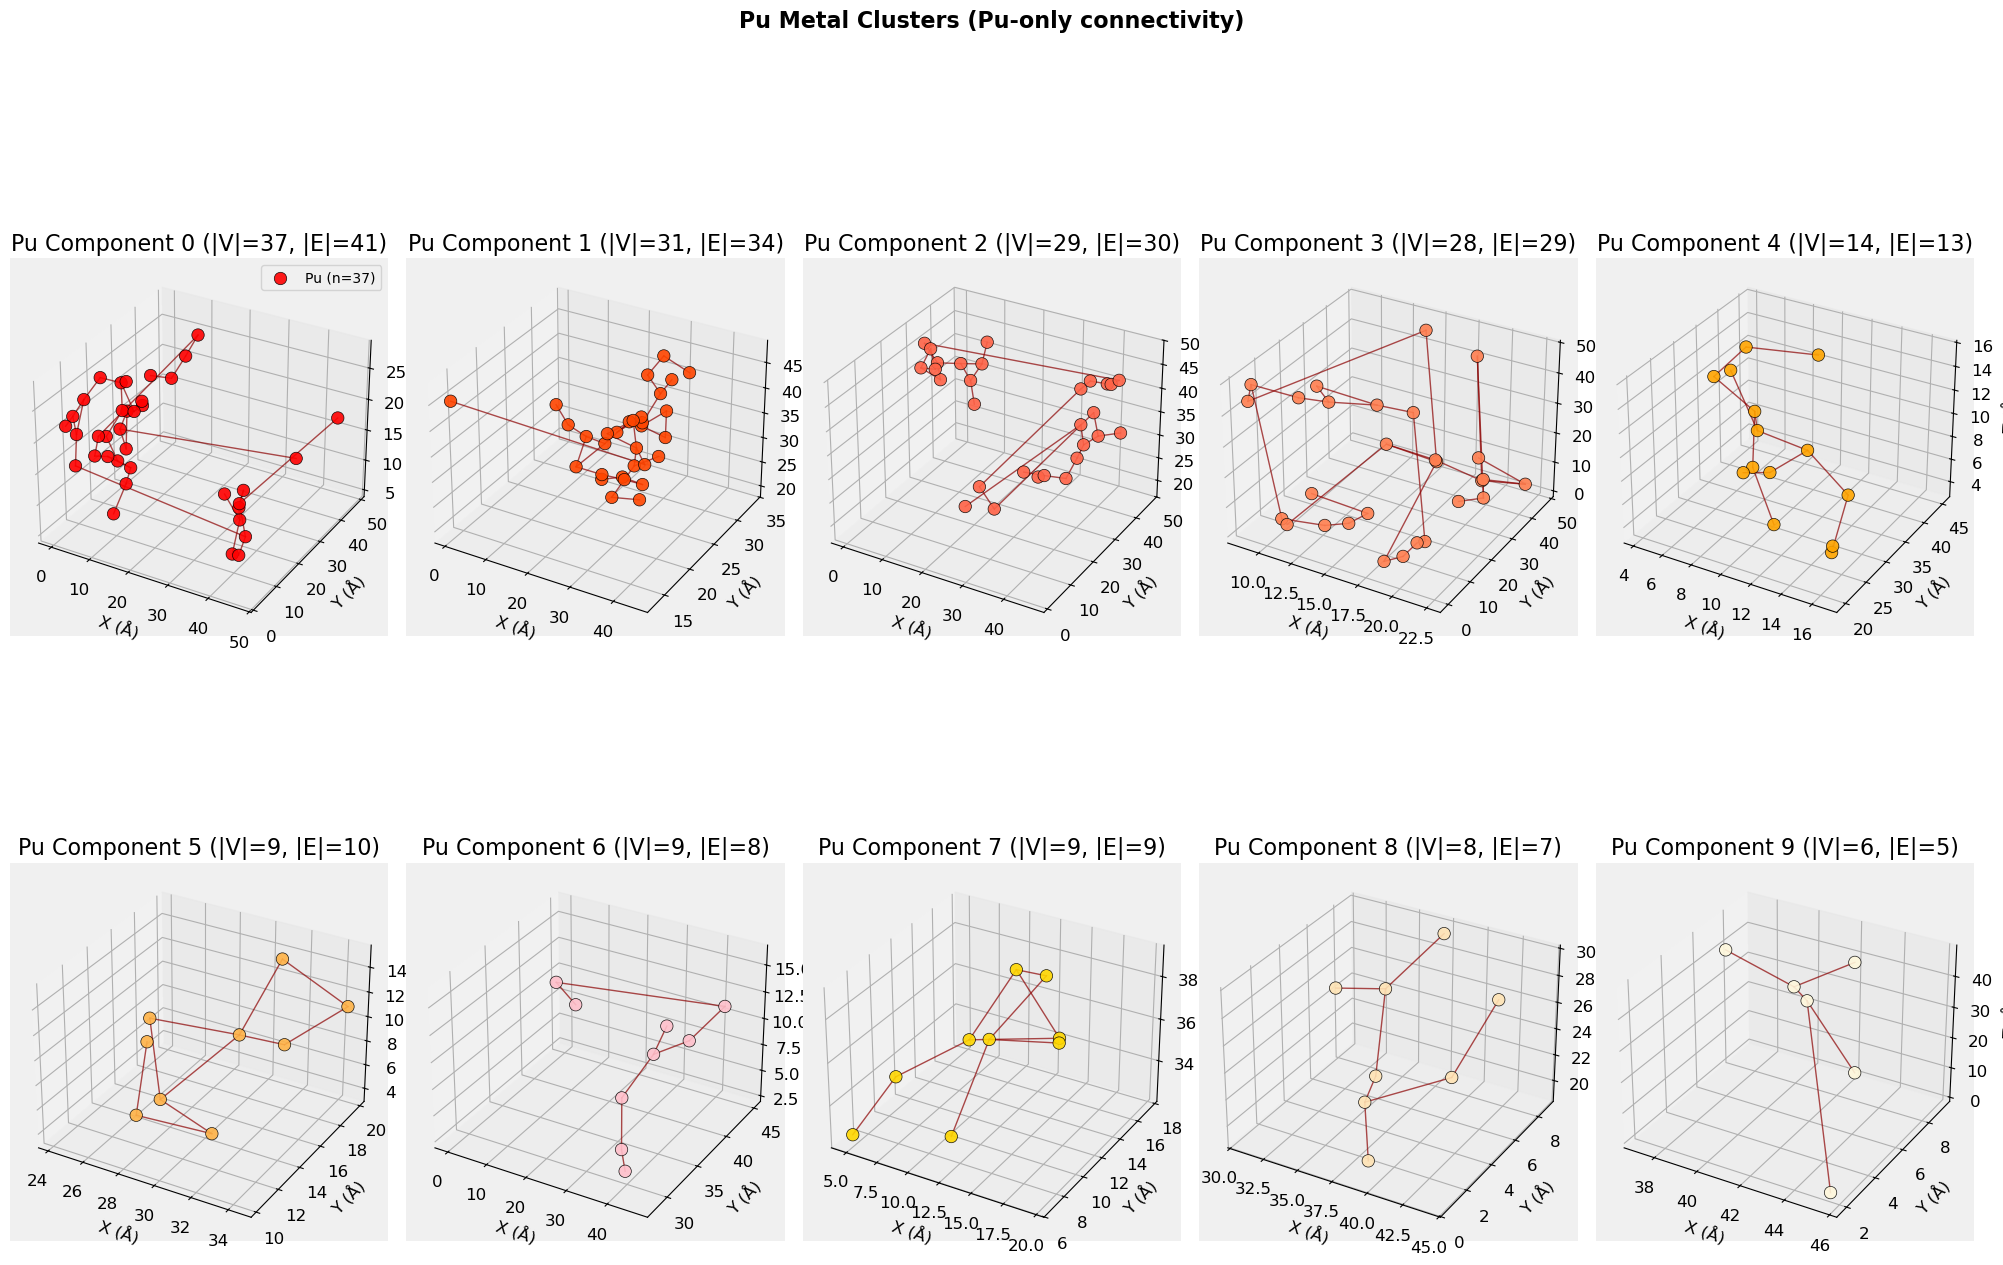

In [14]:
# 3D visualization using standardized plotting functions
plot_3d_graph_components_pu_only(G, data=data0, names=names, max_components=10)

Computing heatmap with 21 x 21 = 441 points...


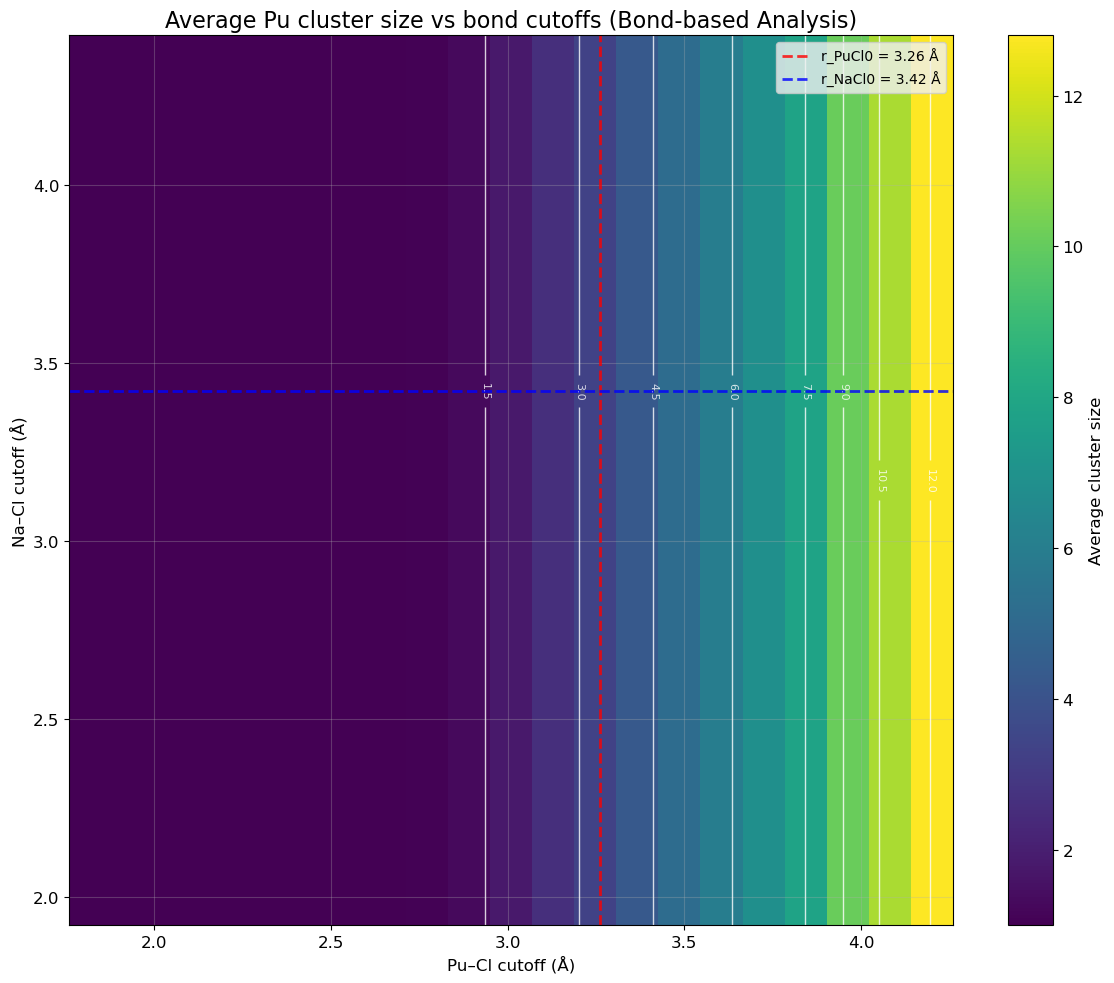

Heatmap Summary:
  Pu-Cl range: 1.76 to 4.26 Å
  Na-Cl range: 1.92 to 4.42 Å
  Min average cluster size: 1.00
  Max average cluster size: 12.80
  Original cutoffs: Pu-Cl=3.26 Å, Na-Cl=3.42 Å


In [15]:
def plot_cluster_size_heatmap_vs_cutoffs(pipe, names, cutoffs, title_suffix=""):
    """
    Plot average cluster size heatmap vs Na-Cl and Pu-Cl cutoffs.
    
    This function creates a heatmap showing how average cluster size changes
    with different bond cutoff values, without modifying global variables.
    
    Args:
        pipe: OVITO pipeline object
        names: Array of atom names/types
        cutoffs: Dictionary of current cutoff values
        title_suffix: Optional suffix for the plot title
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from bondmodifier_utils import configure_bonds_modifier_from_cutoffs, build_shared_anion_graph
    
    # Create a copy of the pipeline to avoid modifying the original
    pipe_copy = pipe
    
    # Define sweep ranges around the RDF-derived cutoffs
    r_PuCl0 = float(cutoffs.get(("Pu","Cl"), cutoffs.get("Pu-Cl", 3.5)))
    r_NaCl0 = float(cutoffs.get(("Na","Cl"), cutoffs.get("Na-Cl", 3.8)))
    
    r_PuCl_vals = np.linspace(max(0.5, r_PuCl0 - 1.5), r_PuCl0 + 1.0, 21)
    r_NaCl_vals = np.linspace(max(0.5, r_NaCl0 - 1.5), r_NaCl0 + 1.0, 21)
    
    # r_PuCl_vals = np.linspace(r_PuCl0, r_PuCl0, 21)
    # r_NaCl_vals = np.linspace(r_NaCl0, r_NaCl0, 21)

    heat = np.zeros((len(r_NaCl_vals), len(r_PuCl_vals)), float)
    
    print(f"Computing heatmap with {len(r_PuCl_vals)} x {len(r_NaCl_vals)} = {len(r_PuCl_vals) * len(r_NaCl_vals)} points...")
    
    for i, r_NaCl in enumerate(r_NaCl_vals):
        for j, r_PuCl in enumerate(r_PuCl_vals):
            # Configure bond cutoffs; mirror symmetric pairs
            pair_cutoffs = {
                ("Pu","Cl"): float(r_PuCl), ("Cl","Pu"): float(r_PuCl),
                ("Na","Cl"): float(r_NaCl), ("Cl","Na"): float(r_NaCl),
            }
            configure_bonds_modifier_from_cutoffs(pipe_copy, pair_cutoffs)
            data_temp = pipe_copy.compute(pipe_copy.source.num_frames-1)
            # Build shared-anion connectivity among Pu atoms only
            sizes_temp, cluster_ids_temp, G_temp = build_shared_anion_graph(data_temp, names, anion="Cl", metals=["Pu"])
            heat[i, j] = float(np.mean(sizes_temp)) if len(sizes_temp) > 0 else 0.0
    
    # Create the plot
    plt.figure(figsize=(12, 10))
    im = plt.imshow(heat, origin='lower', aspect='auto',
                    extent=[r_PuCl_vals[0], r_PuCl_vals[-1], r_NaCl_vals[0], r_NaCl_vals[-1]],
                    cmap='viridis')
    plt.colorbar(im, label='Average cluster size')
    
    # Add contour lines with cluster size labels
    X, Y = np.meshgrid(r_PuCl_vals, r_NaCl_vals)
    contours = plt.contour(X, Y, heat, levels=10, colors='white', alpha=0.8, linewidths=1)
    plt.clabel(contours, fontsize=8, fmt='%.1f')
    
    # Add reference lines for original cutoff values
    plt.axvline(r_PuCl0, color='red', linestyle='--', linewidth=2, alpha=0.8, label=f'r_PuCl0 = {r_PuCl0:.2f} Å')
    plt.axhline(r_NaCl0, color='blue', linestyle='--', linewidth=2, alpha=0.8, label=f'r_NaCl0 = {r_NaCl0:.2f} Å')
    plt.legend()
    
    plt.xlabel('Pu–Cl cutoff (Å)')
    plt.ylabel('Na–Cl cutoff (Å)')
    plt.title(f'Average Pu cluster size vs bond cutoffs{title_suffix}')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"Heatmap Summary:")
    print(f"  Pu-Cl range: {r_PuCl_vals[0]:.2f} to {r_PuCl_vals[-1]:.2f} Å")
    print(f"  Na-Cl range: {r_NaCl_vals[0]:.2f} to {r_NaCl_vals[-1]:.2f} Å")
    print(f"  Min average cluster size: {np.min(heat):.2f}")
    print(f"  Max average cluster size: {np.max(heat):.2f}")
    print(f"  Original cutoffs: Pu-Cl={r_PuCl0:.2f} Å, Na-Cl={r_NaCl0:.2f} Å")
    
    return heat, r_PuCl_vals, r_NaCl_vals

# Call the function to generate the heatmap
heatmap_data = plot_cluster_size_heatmap_vs_cutoffs(pipe, names, cutoffs, " (Bond-based Analysis)")


STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION

1. CLUSTER SIZE DISTRIBUTION ANALYSIS
----------------------------------------


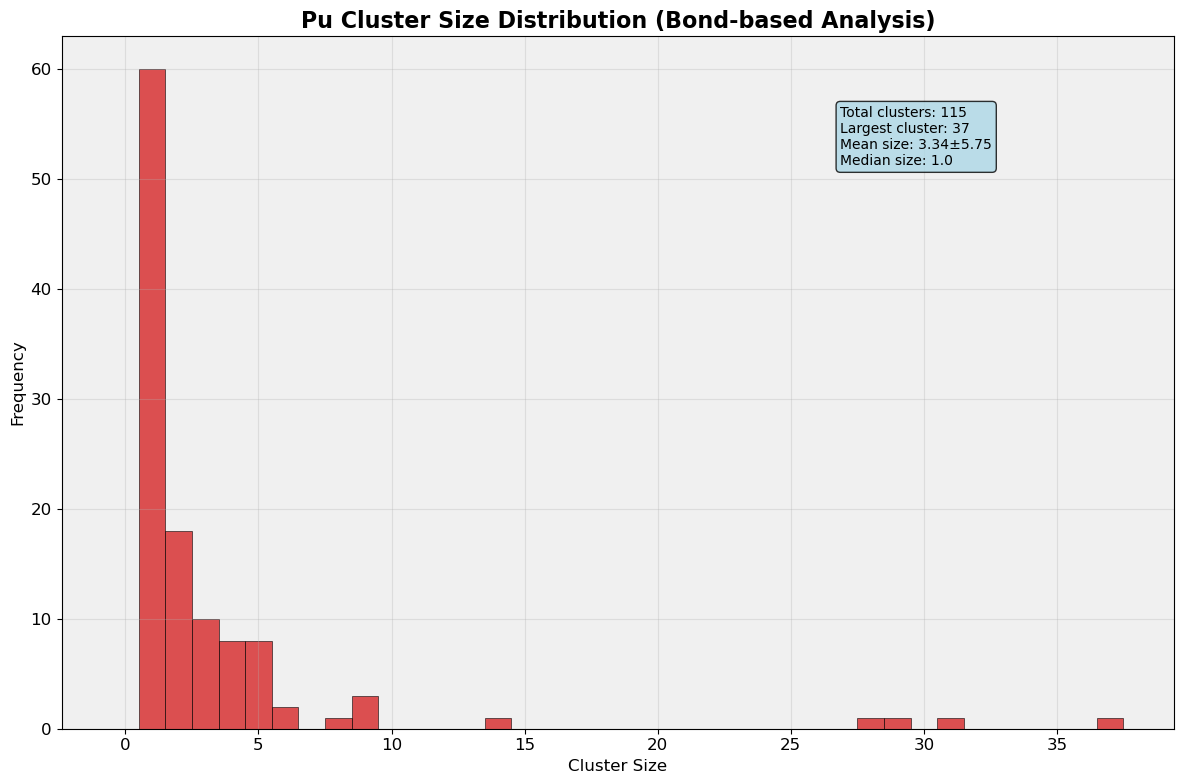

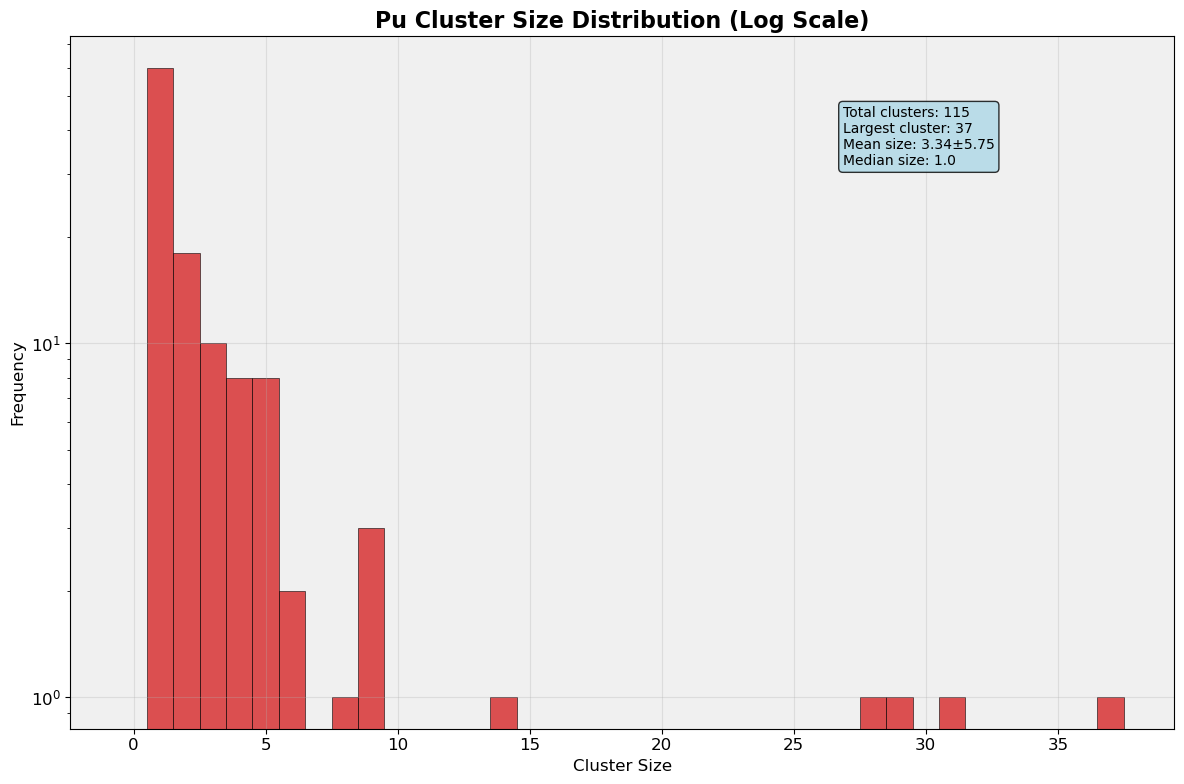

Cluster Statistics:
  Total clusters: 115
  Largest cluster: 37
  Average cluster size: 3.34
  Median cluster size: 1.0
  Standard deviation: 5.75

2. GRAPH STRUCTURE VISUALIZATION
----------------------------------------


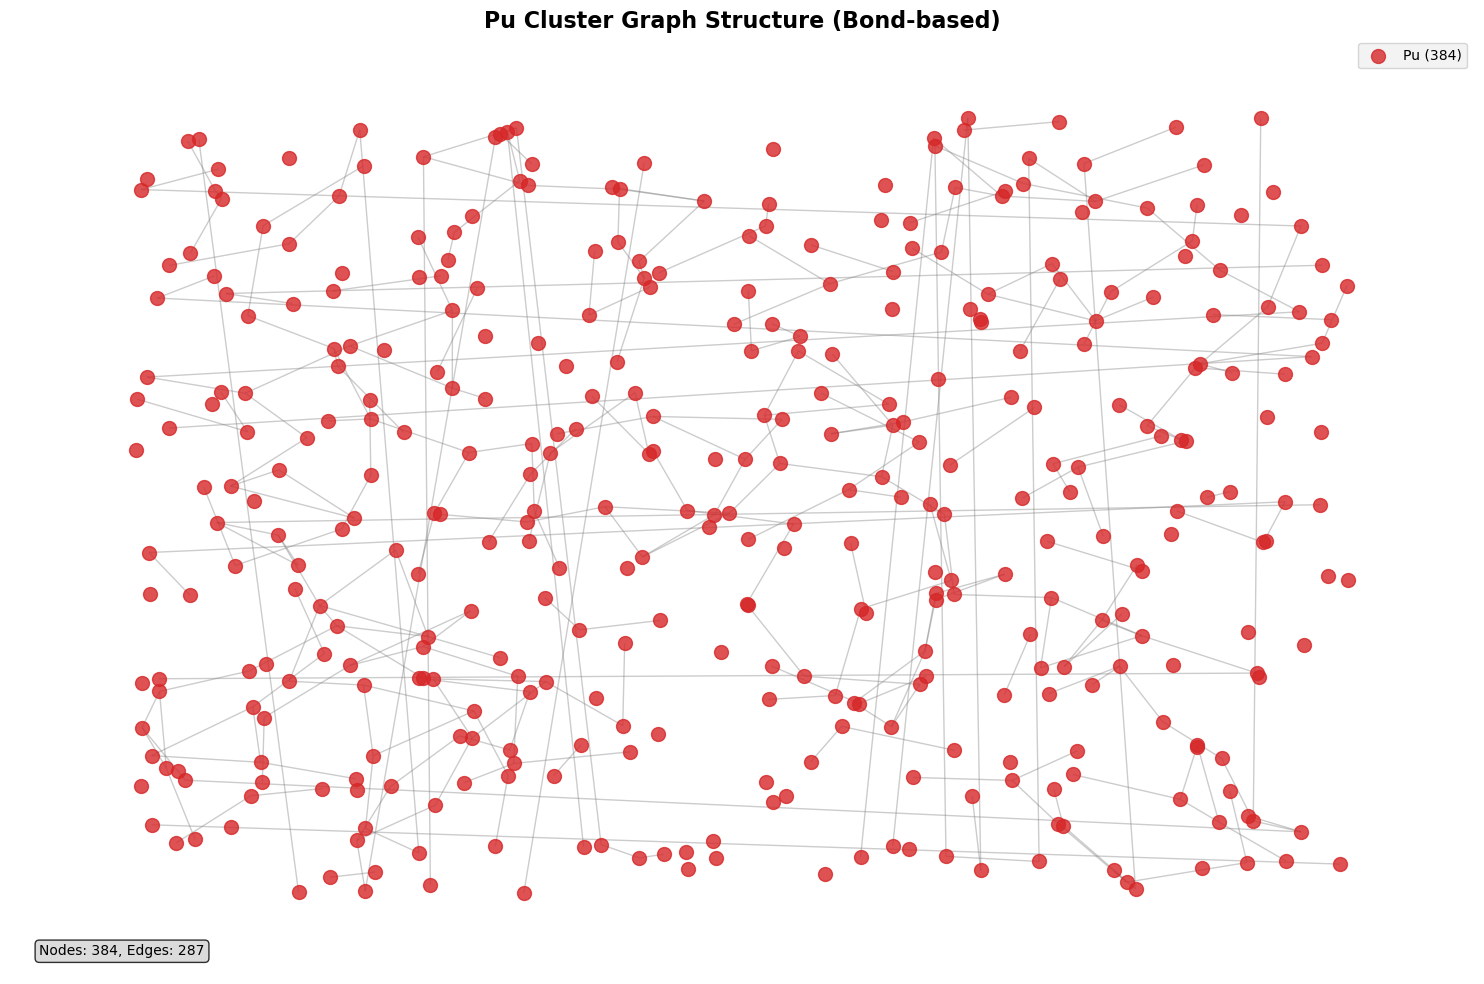

Graph Properties:
  Nodes: 384
  Edges: 287
  Density: 0.0039
  Connected components: 115

3. 3D GRAPH COMPONENTS VISUALIZATION
----------------------------------------


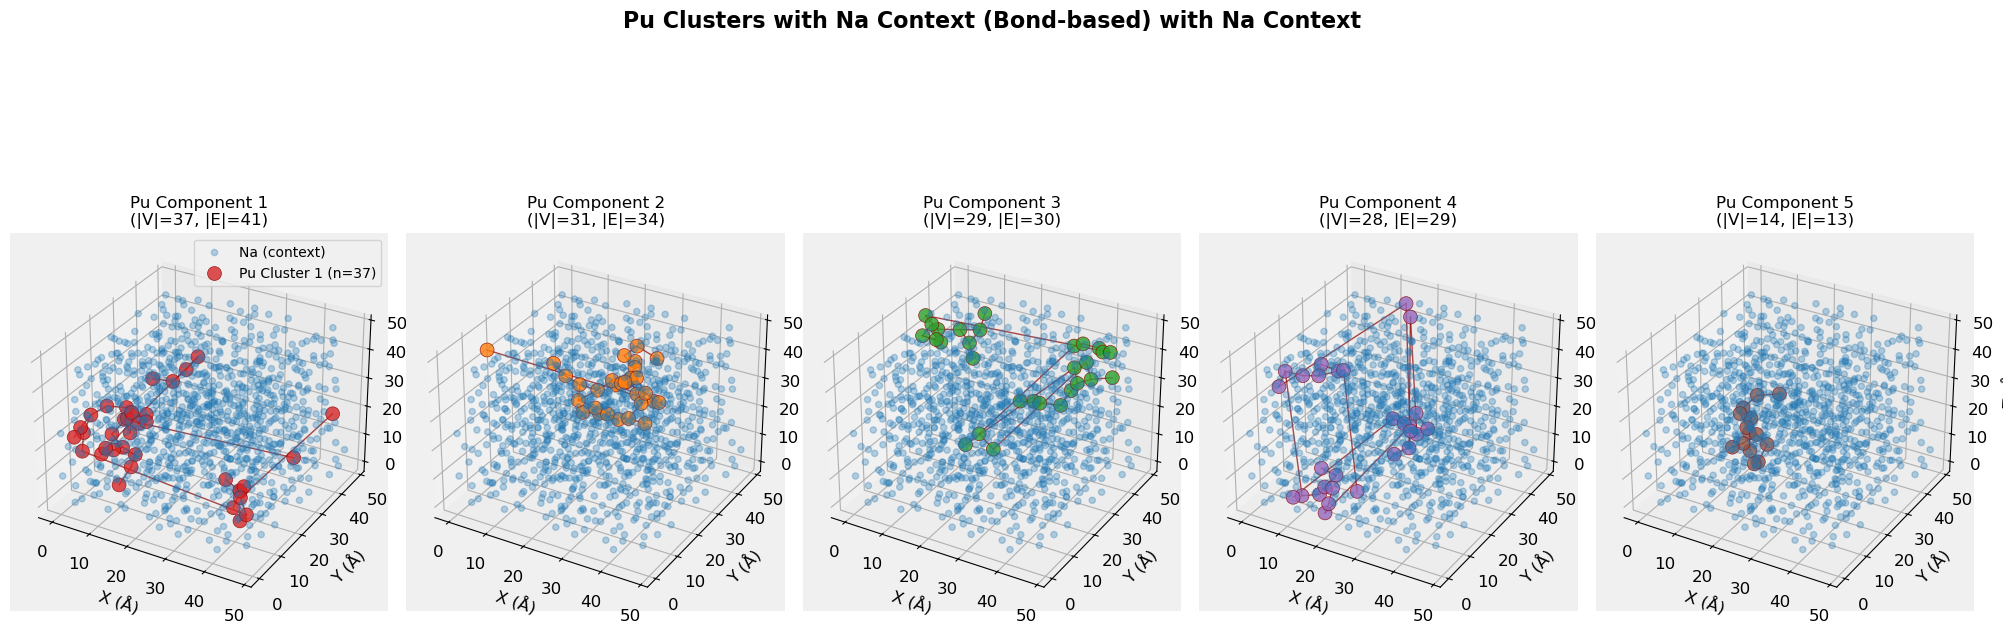

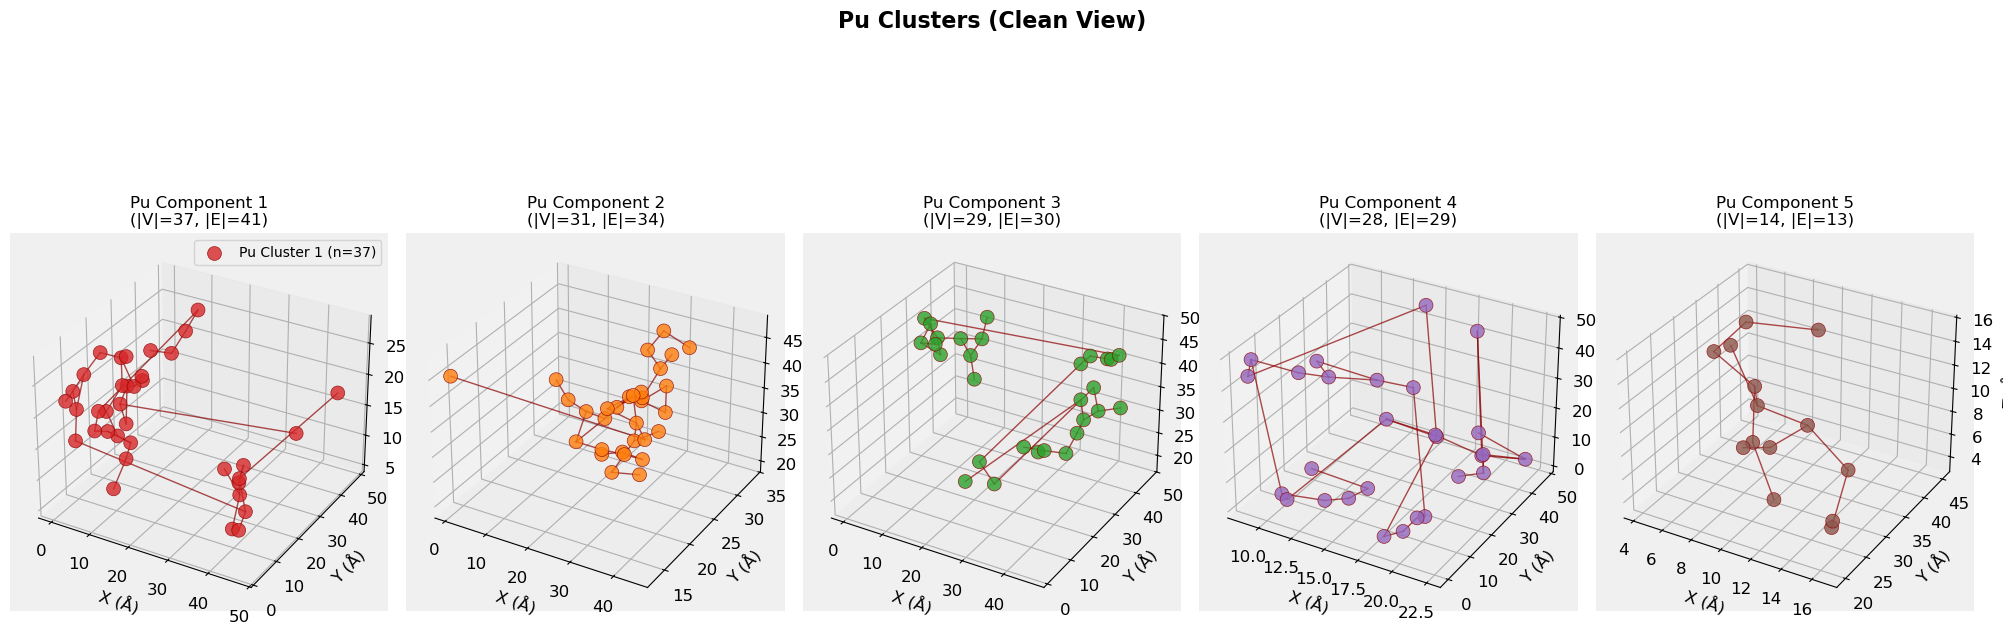


STANDARDIZED PLOTTING DEMONSTRATION COMPLETE


In [16]:
# Comprehensive Standardized Plotting Functions Demonstration
print("=" * 60)
print("STANDARDIZED PLOTTING FUNCTIONS DEMONSTRATION")
print("=" * 60)

# 1. Cluster Size Distribution Analysis
print("\n1. CLUSTER SIZE DISTRIBUTION ANALYSIS")
print("-" * 40)
if len(sizes) > 0:
    # Standard cluster size distribution
    std_plot_cluster_size_distribution(
        sizes, 
        title="Pu Cluster Size Distribution (Bond-based Analysis)",
        log_scale=False
    )
    
    # Log scale version for better visualization of small clusters
    std_plot_cluster_size_distribution(
        sizes, 
        title="Pu Cluster Size Distribution (Log Scale)",
        log_scale=True
    )
    
    print(f"Cluster Statistics:")
    print(f"  Total clusters: {len(sizes)}")
    print(f"  Largest cluster: {max(sizes)}")
    print(f"  Average cluster size: {np.mean(sizes):.2f}")
    print(f"  Median cluster size: {np.median(sizes):.1f}")
    print(f"  Standard deviation: {np.std(sizes):.2f}")
else:
    print("No clusters found for size distribution analysis")

# 2. Graph Structure Visualization
print("\n2. GRAPH STRUCTURE VISUALIZATION")
print("-" * 40)
if G.number_of_nodes() > 0:
    plot_graph_structure(
        G, 
        title="Pu Cluster Graph Structure (Bond-based)",
        show_edges=True,
        show_labels=False
    )
    
    print(f"Graph Properties:")
    print(f"  Nodes: {G.number_of_nodes()}")
    print(f"  Edges: {G.number_of_edges()}")
    print(f"  Density: {nx.density(G):.4f}")
    print(f"  Connected components: {nx.number_connected_components(G)}")
else:
    print("No graph structure available for visualization")

# 3. 3D Graph Components Visualization
print("\n3. 3D GRAPH COMPONENTS VISUALIZATION")
print("-" * 40)
if G.number_of_nodes() > 0:
    # Pu-only components with Na context
    std_plot_3d_graph_components_pu_only(
        G, 
        data=data0, 
        names=names, 
        max_components=5, 
        show_na_context=True,
        title="Pu Clusters with Na Context (Bond-based)"
    )
    
    # Pu-only components without Na context for cleaner view
    std_plot_3d_graph_components_pu_only(
        G, 
        data=data0, 
        names=names, 
        max_components=5, 
        show_na_context=False,
        title="Pu Clusters (Clean View)"
    )
else:
    print("No graph components available for 3D visualization")

print("\n" + "=" * 60)
print("STANDARDIZED PLOTTING DEMONSTRATION COMPLETE")
print("=" * 60)


In [17]:
# Quick Access Plotting Functions
# Use these functions for quick plotting without running the full demonstration

def quick_cluster_size_plot(sizes_list, title_suffix=""):
    """Quick cluster size distribution plot"""
    std_plot_cluster_size_distribution(
        sizes_list, 
        title=f"Pu Cluster Size Distribution{title_suffix}",
        log_scale=False
    )

def quick_graph_structure_plot(graph, title_suffix=""):
    """Quick graph structure plot"""
    plot_graph_structure(
        graph, 
        title=f"Pu Graph Structure{title_suffix}",
        show_edges=True,
        show_labels=False
    )

def quick_3d_components_plot(graph, data, names, max_comp=6, show_na=True, title_suffix=""):
    """Quick 3D components plot"""
    std_plot_3d_graph_components_pu_only(
        graph, 
        data=data, 
        names=names, 
        max_components=max_comp, 
        show_na_context=show_na,
        title=f"Pu Clusters{title_suffix}"
    )

def quick_all_plots():
    """Run all quick plots with current data"""
    print("Running all quick plots...")
    
    if len(sizes) > 0:
        quick_cluster_size_plot(sizes, " (Bond-based)")
    
    if G.number_of_nodes() > 0:
        quick_graph_structure_plot(G, " (Bond-based)")
        quick_3d_components_plot(G, data0, names, 6, True, " (Bond-based)")

# Example usage:
# quick_cluster_size_plot(sizes, " (Custom Title)")
# quick_graph_structure_plot(G, " (Custom Title)")
# quick_3d_components_plot(G, data0, names, 6, True, " (Custom Title)")
# quick_all_plots()  # Run all plots at once


# Standardized Plotting Functions Summary

This notebook now includes comprehensive standardized plotting functions for Pu cluster analysis:

## Available Plotting Functions

### 1. **Cluster Size Distribution**
- `plot_cluster_size_distribution()` - Standardized histogram with statistics
- `quick_cluster_size_plot()` - Quick access version
- Features: Log scale option, comprehensive statistics, professional styling

### 2. **Graph Structure Visualization**
- `plot_graph_structure()` - 2D graph visualization with species coloring
- `quick_graph_structure_plot()` - Quick access version
- Features: Species-colored nodes, optional edges/labels, summary statistics

### 3. **3D Graph Components**
- `plot_3d_graph_components()` - General 3D component visualization
- `plot_3d_graph_components_pu_only()` - Pu-specific with Na context
- `quick_3d_components_plot()` - Quick access version
- Features: Multiple subplots, area-based edge widths, optional Na context

### 4. **Coordination Histograms**
- `plot_coordination_histograms()` - Standardized coordination analysis
- Features: Error bars, mean lines, statistical summaries

## Usage Examples

```python
# Individual plots
quick_cluster_size_plot(sizes, " (Custom Analysis)")
quick_graph_structure_plot(G, " (Custom Analysis)")
quick_3d_components_plot(G, data0, names, 6, True, " (Custom Analysis)")

# Run all plots at once
quick_all_plots()
```

## Benefits
- **Consistent styling** across all notebooks
- **Professional appearance** suitable for publications
- **Robust error handling** prevents plotting failures
- **Easy customization** with optional parameters
- **Comprehensive statistics** automatically included


In [18]:
# Sanity check: Count atoms of each type
print("=" * 60)
print("ATOM COUNT SANITY CHECK")
print("=" * 60)

# Count atoms by species
from collections import Counter
atom_counts = Counter(names)

print("Atom counts by species:")
for species, count in sorted(atom_counts.items()):
    print(f"  {species}: {count:,} atoms")

print(f"\nTotal atoms: {len(names):,}")

# Verify this matches the coordination analysis sample sizes
print("\nCoordination analysis sample sizes:")
print("(These should match the atom counts above)")

# Check if we have the coord_data from previous analysis
if 'coord_data' in locals():
    for central_species in ['Pu', 'Na', 'Cl']:
        if central_species in coord_data:
            # Get the first neighbor species to check sample size
            first_neighbor = next(iter(coord_data[central_species].values()))
            sample_size = len(first_neighbor)
            expected_size = atom_counts.get(central_species, 0)
            match_status = "✓" if sample_size == expected_size else "✗"
            print(f"  {central_species}: n={sample_size} (expected: {expected_size}) {match_status}")
else:
    print("  Run coordination analysis first to see sample size verification")

# Additional system information
print(f"\nSystem information:")
print(f"  Frame: {pipe.source.num_frames} total frames")
print(f"  Current frame: 0 (first frame)")
print(f"  Box dimensions: {data0.cell.matrix}")

# Composition analysis
total_atoms = len(names)
print(f"\nComposition (mole fractions):")
for species, count in sorted(atom_counts.items()):
    mole_fraction = count / total_atoms
    print(f"  {species}: {mole_fraction:.4f} ({count/total_atoms*100:.2f}%)")

print("=" * 60)


ATOM COUNT SANITY CHECK
Atom counts by species:
  Cl: 2,176 atoms
  Na: 1,024 atoms
  Pu: 384 atoms

Total atoms: 3,584

Coordination analysis sample sizes:
(These should match the atom counts above)
  Run coordination analysis first to see sample size verification

System information:
  Frame: 14615 total frames
  Current frame: 0 (first frame)
  Box dimensions: [[48.43388029  0.          0.         -0.19611895]
 [ 0.         48.43388029  0.         -0.19611895]
 [ 0.          0.         48.43388029 -0.19611895]]

Composition (mole fractions):
  Cl: 0.6071 (60.71%)
  Na: 0.2857 (28.57%)
  Pu: 0.1071 (10.71%)


In [19]:
cutoffs


{('Pu', 'Cl'): 3.2600000000000002,
 ('Cl', 'Pu'): 3.2600000000000002,
 ('Na', 'Cl'): 3.42,
 ('Cl', 'Na'): 3.42}

In [20]:
# ['a','b','÷c'].count()







BOND-BASED COORDINATION HISTOGRAM ANALYSIS
Analyzing coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]

Plotting coordination histogram for Pu:
{np.str_('Cl'): [1, 6, 4, 5, 3, 6, 6, 5, 7, 5, 3, 4, 6, 7, 3, 6, 5, 6, 4, 6, 5, 3, 4, 5, 6, 6, 5, 3, 3, 4, 6, 6, 5, 5, 3, 6, 6, 6, 6, 6, 5, 6, 3, 6, 5, 5, 5, 6, 5, 6, 7, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 5, 6, 3, 6, 5, 6, 6, 5, 6, 6, 5, 4, 6, 6, 6, 6, 7, 6, 5, 6, 6, 6, 5, 6, 6, 5, 6, 6, 5, 6, 4, 5, 4, 5, 5, 6, 3, 6, 7, 6, 6, 6, 5, 7, 6, 7, 7, 6, 6, 6, 6, 5, 5, 6, 6, 4, 6, 5, 6, 5, 6, 5, 6, 4, 5, 4, 6, 6, 6, 4, 6, 6, 7, 5, 5, 6, 6, 6, 6, 6, 6, 7, 5, 4, 6, 5, 6, 5, 5, 7, 6, 7, 4, 3, 4, 4, 3, 6, 5, 4, 5, 6, 7, 5, 4, 7, 7, 5, 6, 5, 5, 7, 5, 4, 6, 6, 6, 6, 6, 5, 6, 6, 6, 7, 5, 6, 6, 5, 3, 3, 6, 4, 6, 5, 6, 6, 6, 7, 5, 5, 5, 5, 5, 6, 7, 6, 3, 6, 6, 7, 7, 6, 6, 6, 5, 5, 6, 6, 5, 6, 7, 5, 6, 7, 5, 6, 5, 5, 5, 5, 6, 5, 6, 6, 5, 6, 5, 6, 6, 6, 6, 6, 4, 6, 6, 6, 6, 6, 6, 6, 5, 4, 4, 6, 2, 5, 5, 6, 7, 6, 5, 6, 5, 6, 6, 6, 7, 5, 7, 6

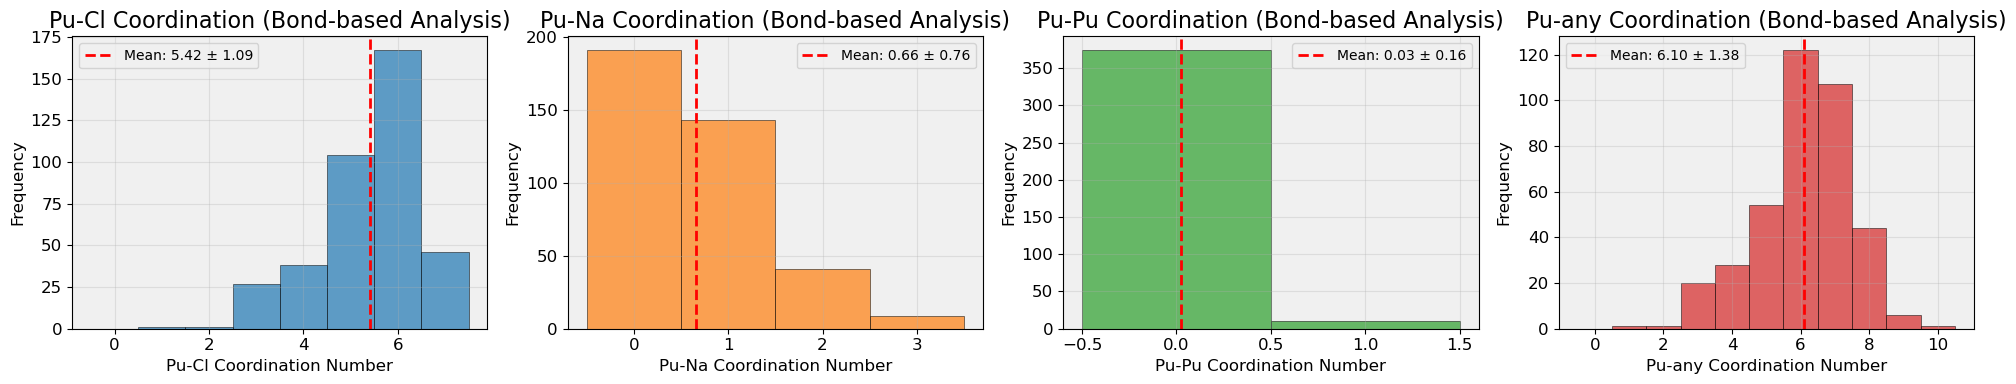


Plotting coordination histogram for Na:
{np.str_('Cl'): [2, 2, 2, 2, 4, 3, 3, 3, 2, 4, 3, 4, 3, 4, 4, 1, 2, 3, 4, 2, 3, 3, 4, 3, 4, 3, 2, 2, 7, 4, 5, 2, 5, 2, 3, 5, 4, 4, 3, 3, 6, 2, 4, 2, 4, 3, 3, 3, 5, 2, 7, 1, 3, 5, 3, 5, 3, 3, 3, 2, 5, 4, 2, 2, 3, 2, 5, 2, 6, 4, 1, 3, 1, 6, 4, 3, 5, 4, 5, 3, 4, 2, 3, 4, 5, 3, 3, 3, 4, 1, 3, 5, 3, 4, 4, 3, 6, 5, 5, 6, 4, 4, 3, 3, 5, 6, 5, 5, 3, 4, 4, 4, 4, 4, 6, 4, 5, 5, 6, 4, 4, 3, 4, 5, 4, 4, 4, 4, 5, 6, 3, 4, 3, 3, 4, 4, 5, 4, 3, 4, 2, 4, 4, 4, 5, 5, 4, 5, 4, 3, 4, 4, 4, 4, 3, 4, 2, 3, 3, 3, 4, 4, 4, 5, 4, 1, 4, 4, 3, 4, 4, 1, 3, 0, 4, 4, 5, 2, 1, 4, 5, 4, 4, 4, 3, 4, 4, 5, 5, 5, 4, 5, 3, 6, 5, 3, 3, 4, 4, 5, 4, 5, 4, 5, 5, 4, 5, 4, 3, 4, 4, 4, 5, 4, 5, 6, 3, 4, 5, 5, 4, 5, 2, 4, 4, 5, 4, 4, 6, 5, 2, 6, 5, 5, 3, 5, 5, 5, 6, 5, 3, 4, 5, 5, 4, 4, 2, 4, 5, 5, 2, 3, 3, 4, 5, 5, 2, 6, 4, 2, 4, 4, 4, 4, 5, 4, 5, 5, 4, 6, 4, 4, 4, 6, 4, 4, 5, 4, 6, 5, 5, 5, 4, 6, 5, 4, 2, 6, 6, 3, 3, 4, 3, 5, 4, 5, 5, 3, 5, 5, 4, 5, 5, 2, 4, 3, 4, 5, 4, 5, 4, 3, 6, 2, 

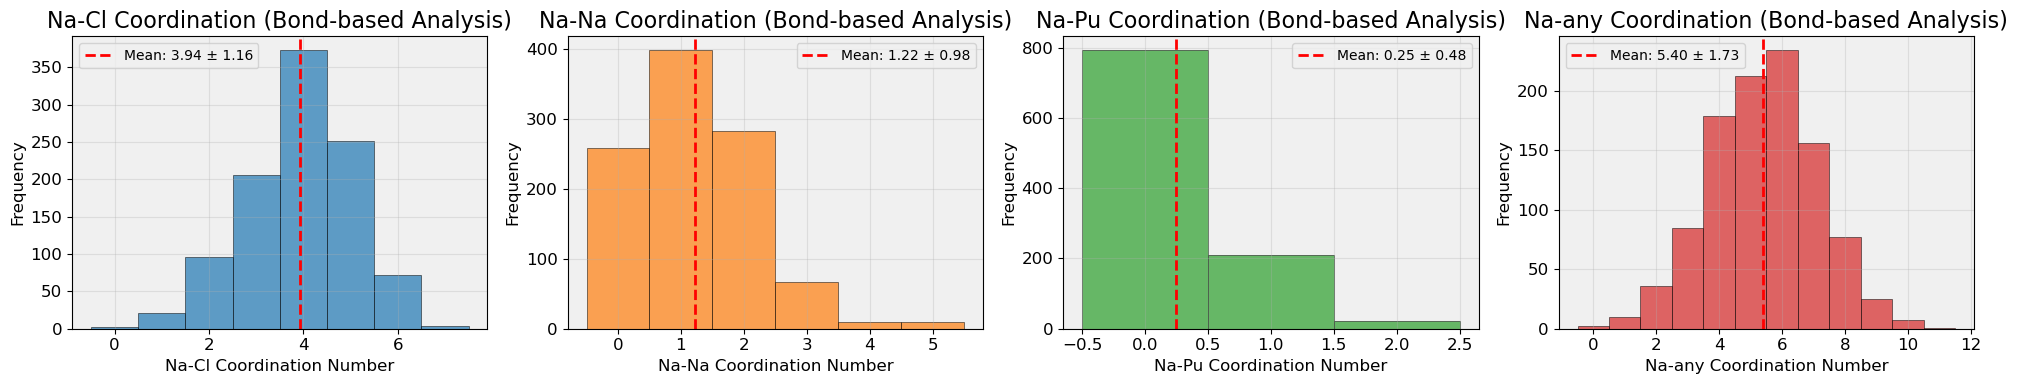


Plotting coordination histogram for Cl:
{np.str_('Cl'): [4, 2, 3, 3, 4, 4, 4, 3, 1, 1, 1, 3, 5, 3, 2, 5, 4, 2, 7, 2, 3, 2, 6, 2, 7, 3, 3, 0, 2, 3, 2, 1, 4, 6, 7, 3, 4, 5, 2, 0, 5, 1, 6, 2, 2, 2, 5, 1, 2, 2, 4, 2, 3, 7, 5, 3, 2, 2, 1, 3, 5, 3, 5, 4, 2, 1, 3, 4, 5, 2, 2, 5, 4, 4, 6, 4, 6, 1, 3, 4, 2, 6, 1, 3, 2, 3, 3, 3, 7, 1, 4, 6, 5, 4, 3, 3, 3, 6, 2, 3, 5, 3, 2, 4, 3, 3, 2, 5, 3, 6, 2, 2, 5, 5, 3, 4, 3, 3, 1, 4, 3, 2, 1, 2, 4, 3, 3, 2, 3, 5, 5, 3, 1, 1, 1, 4, 4, 3, 3, 2, 4, 2, 3, 5, 3, 3, 2, 5, 3, 2, 4, 3, 3, 4, 4, 4, 3, 5, 3, 6, 5, 3, 3, 3, 4, 6, 5, 4, 3, 0, 3, 4, 5, 4, 2, 1, 2, 4, 1, 2, 2, 3, 2, 2, 1, 5, 4, 2, 3, 1, 5, 5, 5, 2, 5, 3, 3, 5, 4, 3, 1, 6, 3, 6, 5, 5, 5, 5, 4, 2, 4, 6, 3, 4, 3, 4, 6, 3, 5, 5, 6, 4, 4, 4, 4, 5, 5, 4, 3, 5, 5, 4, 6, 5, 5, 4, 6, 4, 4, 3, 5, 6, 6, 7, 6, 5, 1, 3, 8, 3, 5, 5, 5, 6, 3, 3, 4, 5, 3, 3, 3, 4, 3, 7, 6, 5, 5, 5, 4, 5, 5, 4, 4, 6, 4, 3, 6, 6, 5, 4, 5, 4, 4, 5, 3, 4, 4, 5, 4, 3, 4, 5, 4, 3, 4, 5, 3, 3, 3, 4, 5, 4, 6, 3, 2, 5, 4, 5, 6, 5, 4, 4, 5, 5, 

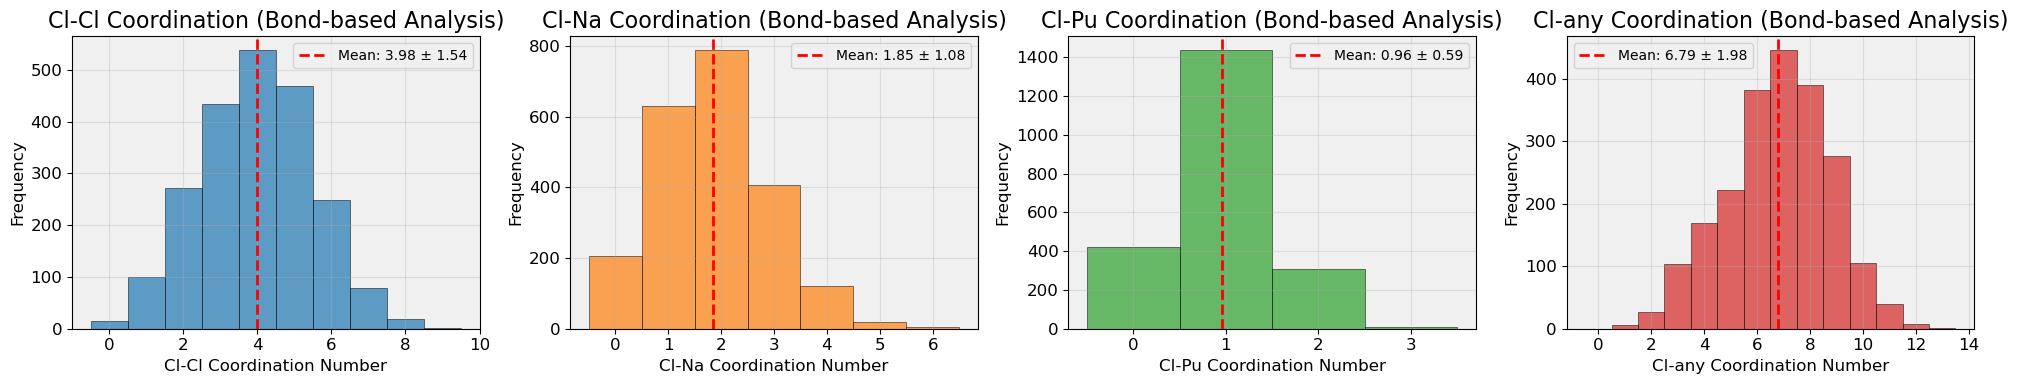


BOND-BASED COORDINATION ANALYSIS COMPLETE


In [21]:
def analyze_bond_coordination(data, names, pair_cutoffs=None):
    """
    Analyze coordination using bond-based analysis (similar to analyze_voronoi_coordination).
    
    This function computes neighbor-count distributions by species using bond cutoffs
    instead of Voronoi tessellation, making it suitable for bond-based cluster analysis.
    
    Parameters:
        data: OVITO data object containing particle information
        names: Array of atom names/types
        pair_cutoffs: Dictionary of bond cutoffs for different species pairs
    
    Returns:
        dict: Coordination data organized by central species and neighbor species
              Includes additional 'any' coordination structures:
              - coord_data[sp_c]['any']: total coordination for each central species
              - coord_data['any'][sp_n]: coordination from any central species to each neighbor species
              - coord_data['any']['any']: total coordination across all species pairs
    """
    import numpy as np
    from collections import defaultdict
    
    # Get unique species
    unique_species = sorted(list(set(names)))
    print(f"Analyzing coordination for species: {unique_species}")
    
    # Initialize coordination data structure
    coord_data = {sp_c: {sp_n: [] for sp_n in unique_species} for sp_c in unique_species}
    
    # Add 'any' coordination structures
    coord_data['any'] = {sp_n: [] for sp_n in unique_species}
    coord_data['any']['any'] = []
    
    # Get positions and create species mapping
    positions = data.particles.positions[:]
    species_idx = {sp: i for i, sp in enumerate(unique_species)}
    
    # Create species array for each atom
    atom_species = np.array([species_idx[name] for name in names])
    
    # Calculate coordination for each atom
    for i, (pos_i, sp_i) in enumerate(zip(positions, names)):
        neighbors = []
        
        # Find neighbors within cutoff distance
        for j, (pos_j, sp_j) in enumerate(zip(positions, names)):
            if i == j:
                continue
                
            # Calculate distance
            dist = np.linalg.norm(pos_j - pos_i)
            
            # Check if within cutoff (use default or specific pair cutoff)
            if pair_cutoffs:
                cutoff_key = (sp_i, sp_j)
                if cutoff_key in pair_cutoffs:
                    cutoff = pair_cutoffs[cutoff_key]
                else:
                    # Use default cutoff if specific pair not found
                    cutoff = 4.0  # Default cutoff
            else:
                cutoff = 4.0  # Default cutoff
                
            if dist <= cutoff:
                neighbors.append(sp_j)
        
        # Store coordination counts for specific species pairs
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data[sp_i][neighbor_sp].append(count)
        
        # Store total coordination for this central species (any neighbors)
        total_coord = len(neighbors)
        coord_data[sp_i]['any'] = coord_data[sp_i].get('any', [])
        coord_data[sp_i]['any'].append(total_coord)
        
        # Store coordination counts for 'any' central species to each neighbor species
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data['any'][neighbor_sp].append(count)
        
        # Store total coordination for 'any'-'any' (all coordination)
        coord_data['any']['any'].append(total_coord)
    
    return coord_data

def plot_bond_coordination_histograms(coord_data, central_species, title_suffix=""):
    """
    Plot coordination histograms for bond-based analysis.
    
    Parameters:
        coord_data: Coordination data from analyze_bond_coordination
        central_species: Species to plot coordination for
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if central_species not in coord_data:
        print(f"No coordination data found for species: {central_species}")
        return
    
    # Get coordination data for the central species
    species_data = coord_data[central_species]
    print(species_data)
    
    # Filter out empty neighbor species
    neighbor_species = [sp for sp, counts in species_data.items() if counts and any(counts)]
    print(neighbor_species)
    
    if not neighbor_species:
        print(f"No coordination data found for {central_species}")
        return
    
    # Create subplots
    n_neighbors = len(neighbor_species)
    fig, axes = plt.subplots(1, n_neighbors, figsize=(5*n_neighbors, 4))
    if n_neighbors == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, neighbor_sp in enumerate(neighbor_species):
        counts = species_data[neighbor_sp]
        
        if not counts:
            continue
            
        # Create histogram
        max_coord = max(counts) if counts else 0
        bins = np.arange(0, max_coord + 2) - 0.5
        
        axes[idx].hist(counts, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                      edgecolor='black', linewidth=0.5)
        
        # Add statistics
        mean_coord = np.mean(counts)
        std_coord = np.std(counts)
        axes[idx].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
        
        axes[idx].set_xlabel(f'{central_species}-{neighbor_sp} Coordination Number')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{central_species}-{neighbor_sp} Coordination{title_suffix}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # Print statistics
        print(f'{central_species}-{neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
    
    plt.tight_layout()
    plt.show()

# Test the coordination analysis with current data
print("=" * 60)
print("BOND-BASED COORDINATION HISTOGRAM ANALYSIS")
print("=" * 60)

# Analyze coordination using bond cutoffs
coord_data = analyze_bond_coordination(data0, names, pair_cutoffs=cutoffs)

# Plot coordination histograms for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data and any(any(counts) for counts in coord_data[species].values()):
        print(f"\nPlotting coordination histogram for {species}:")
        plot_bond_coordination_histograms(coord_data, species, " (Bond-based Analysis)")
    else:
        print(f"No coordination data available for {species}")

print("\n" + "=" * 60)
print("BOND-BASED COORDINATION ANALYSIS COMPLETE")
print("=" * 60)


In [22]:
# Test the enhanced coordination analysis function
print("=" * 60)
print("TESTING ENHANCED COORDINATION ANALYSIS")
print("=" * 60)

# Re-run the enhanced coordination analysis
coord_data_enhanced = analyze_bond_coordination(data0, names, pair_cutoffs=cutoffs)

# Verify all coordination structures are present
print("\nVerifying coordination data structures:")
print("-" * 40)

# Check species-specific coordination
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data_enhanced:
        print(f"\n{species} coordination data:")
        for neighbor_sp in ['Pu', 'Na', 'Cl', 'any']:
            if neighbor_sp in coord_data_enhanced[species]:
                counts = coord_data_enhanced[species][neighbor_sp]
                if counts:
                    mean_coord = np.mean(counts)
                    print(f"  {species}-{neighbor_sp}: {mean_coord:.2f} ± {np.std(counts):.2f} (n={len(counts)})")
                else:
                    print(f"  {species}-{neighbor_sp}: No data")

# Check 'any' central species coordination
print(f"\n'any' central species coordination data:")
for neighbor_sp in ['Pu', 'Na', 'Cl', 'any']:
    if neighbor_sp in coord_data_enhanced['any']:
        counts = coord_data_enhanced['any'][neighbor_sp]
        if counts:
            mean_coord = np.mean(counts)
            print(f"  any-{neighbor_sp}: {mean_coord:.2f} ± {np.std(counts):.2f} (n={len(counts)})")
        else:
            print(f"  any-{neighbor_sp}: No data")

# Verify data consistency
print(f"\nData consistency checks:")
print("-" * 40)

# Check that 'any' coordination equals sum of specific coordinations for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data_enhanced and 'any' in coord_data_enhanced[species]:
        any_coord = coord_data_enhanced[species]['any']
        specific_coord_sum = []
        
        # Sum up specific coordinations for this species
        for neighbor_sp in ['Pu', 'Na', 'Cl']:
            if neighbor_sp in coord_data_enhanced[species]:
                specific_coord_sum.extend(coord_data_enhanced[species][neighbor_sp])
        
        if any_coord and specific_coord_sum:
            any_mean = np.mean(any_coord)
            specific_mean = np.mean(specific_coord_sum)
            diff = abs(any_mean - specific_mean)
            status = "✓" if diff < 0.01 else "✗"
            print(f"  {species} any vs sum of specific: {any_mean:.2f} vs {specific_mean:.2f} (diff: {diff:.3f}) {status}")

# Check that 'any'-'any' equals sum of all 'any' coordinations
if 'any' in coord_data_enhanced and 'any' in coord_data_enhanced['any']:
    any_any_coord = coord_data_enhanced['any']['any']
    all_any_coord = []
    
    # Sum up all 'any' coordinations
    for species in ['Pu', 'Na', 'Cl']:
        if species in coord_data_enhanced and 'any' in coord_data_enhanced[species]:
            all_any_coord.extend(coord_data_enhanced[species]['any'])
    
    if any_any_coord and all_any_coord:
        any_any_mean = np.mean(any_any_coord)
        all_any_mean = np.mean(all_any_coord)
        diff = abs(any_any_mean - all_any_mean)
        status = "✓" if diff < 0.01 else "✗"
        print(f"  any-any vs sum of all any: {any_any_mean:.2f} vs {all_any_mean:.2f} (diff: {diff:.3f}) {status}")

print("\n" + "=" * 60)
print("ENHANCED COORDINATION ANALYSIS TEST COMPLETE")
print("=" * 60)


TESTING ENHANCED COORDINATION ANALYSIS
Analyzing coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]

Verifying coordination data structures:
----------------------------------------

Pu coordination data:
  Pu-Pu: 0.03 ± 0.16 (n=384)
  Pu-Na: 0.66 ± 0.76 (n=384)
  Pu-Cl: 5.42 ± 1.09 (n=384)
  Pu-any: 6.10 ± 1.38 (n=384)

Na coordination data:
  Na-Pu: 0.25 ± 0.48 (n=1024)
  Na-Na: 1.22 ± 0.98 (n=1024)
  Na-Cl: 3.94 ± 1.16 (n=1024)
  Na-any: 5.40 ± 1.73 (n=1024)

Cl coordination data:
  Cl-Pu: 0.96 ± 0.59 (n=2176)
  Cl-Na: 1.85 ± 1.08 (n=2176)
  Cl-Cl: 3.98 ± 1.54 (n=2176)
  Cl-any: 6.79 ± 1.98 (n=2176)

'any' central species coordination data:
  any-Pu: 0.65 ± 0.65 (n=3584)
  any-Na: 1.54 ± 1.10 (n=3584)
  any-Cl: 4.12 ± 1.47 (n=3584)
  any-any: 6.32 ± 1.95 (n=3584)

Data consistency checks:
----------------------------------------
  Pu any vs sum of specific: 6.10 vs 2.03 (diff: 4.066) ✗
  Na any vs sum of specific: 5.40 vs 1.80 (diff: 3.601) ✗
  Cl any vs sum of 

PLOTTING NEW COORDINATION STRUCTURES
Pu-Any: 6.10 ± 1.38 (n=384)
Na-Any: 5.40 ± 1.73 (n=1024)
Cl-Any: 6.79 ± 1.98 (n=2176)
Any-Any: 6.32 ± 1.95 (n=3584)


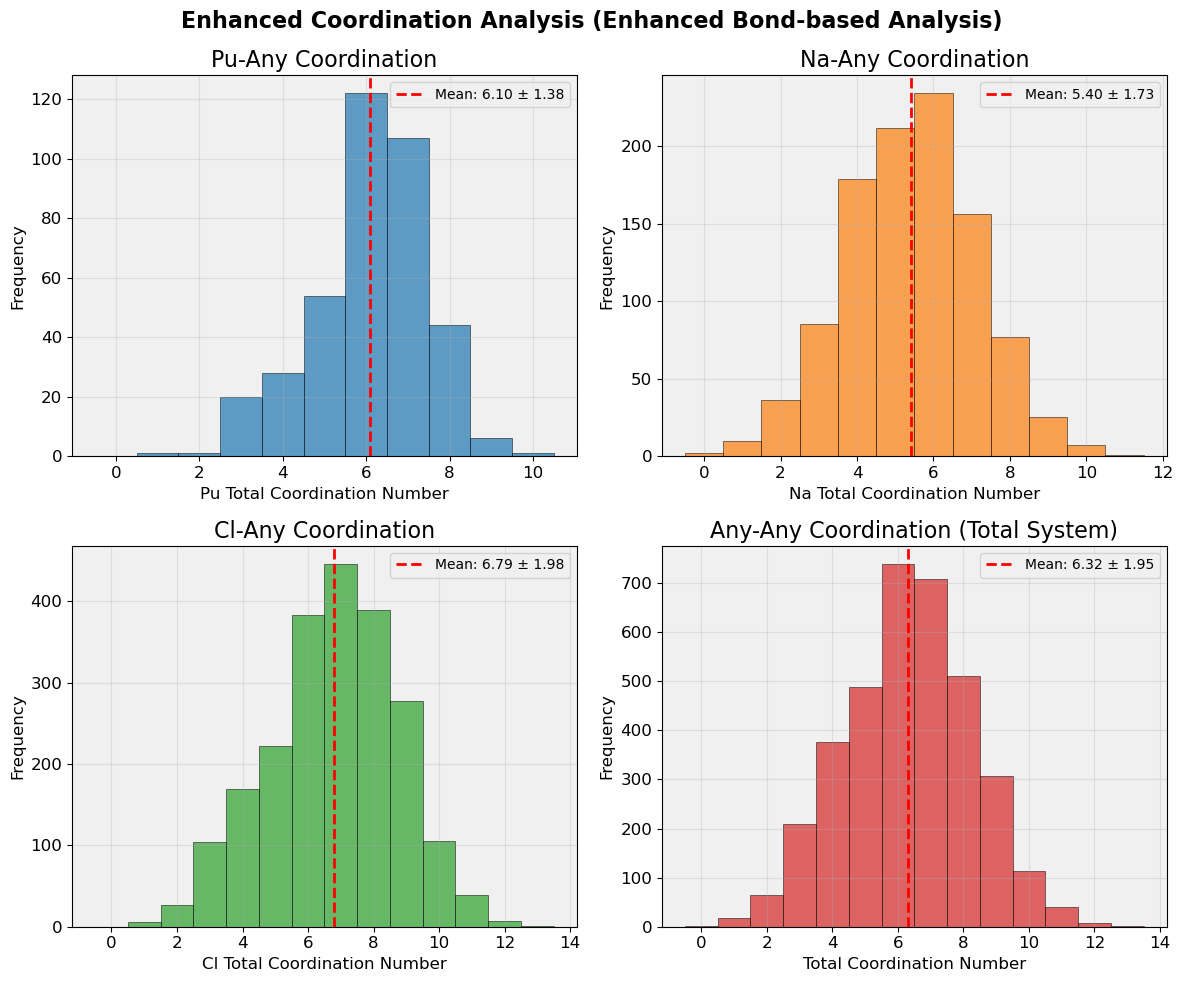


ENHANCED COORDINATION PLOTTING COMPLETE


In [23]:
# Demonstrate plotting with the new 'any' coordination structures
print("=" * 60)
print("PLOTTING NEW COORDINATION STRUCTURES")
print("=" * 60)

def plot_any_coordination_histograms(coord_data, title_suffix=""):
    """
    Plot histograms for the new 'any' coordination structures.
    
    Parameters:
        coord_data: Enhanced coordination data with 'any' structures
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a 2x2 subplot layout
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Enhanced Coordination Analysis{title_suffix}', fontsize=16, fontweight='bold')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Plot 1: Pu-any coordination
    if 'Pu' in coord_data and 'any' in coord_data['Pu']:
        pu_any = coord_data['Pu']['any']
        if pu_any:
            max_coord = max(pu_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[0,0].hist(pu_any, bins=bins, alpha=0.7, color=colors[0], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(pu_any)
            std_coord = np.std(pu_any)
            axes[0,0].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[0,0].set_xlabel('Pu Total Coordination Number')
            axes[0,0].set_ylabel('Frequency')
            axes[0,0].set_title('Pu-Any Coordination')
            axes[0,0].legend()
            axes[0,0].grid(True, alpha=0.3)
            
            print(f'Pu-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(pu_any)})')
    
    # Plot 2: Na-any coordination
    if 'Na' in coord_data and 'any' in coord_data['Na']:
        na_any = coord_data['Na']['any']
        if na_any:
            max_coord = max(na_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[0,1].hist(na_any, bins=bins, alpha=0.7, color=colors[1], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(na_any)
            std_coord = np.std(na_any)
            axes[0,1].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[0,1].set_xlabel('Na Total Coordination Number')
            axes[0,1].set_ylabel('Frequency')
            axes[0,1].set_title('Na-Any Coordination')
            axes[0,1].legend()
            axes[0,1].grid(True, alpha=0.3)
            
            print(f'Na-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(na_any)})')
    
    # Plot 3: Cl-any coordination
    if 'Cl' in coord_data and 'any' in coord_data['Cl']:
        cl_any = coord_data['Cl']['any']
        if cl_any:
            max_coord = max(cl_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[1,0].hist(cl_any, bins=bins, alpha=0.7, color=colors[2], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(cl_any)
            std_coord = np.std(cl_any)
            axes[1,0].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[1,0].set_xlabel('Cl Total Coordination Number')
            axes[1,0].set_ylabel('Frequency')
            axes[1,0].set_title('Cl-Any Coordination')
            axes[1,0].legend()
            axes[1,0].grid(True, alpha=0.3)
            
            print(f'Cl-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(cl_any)})')
    
    # Plot 4: Any-any coordination (total system coordination)
    if 'any' in coord_data and 'any' in coord_data['any']:
        any_any = coord_data['any']['any']
        if any_any:
            max_coord = max(any_any)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            axes[1,1].hist(any_any, bins=bins, alpha=0.7, color=colors[3], 
                          edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(any_any)
            std_coord = np.std(any_any)
            axes[1,1].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                             label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            axes[1,1].set_xlabel('Total Coordination Number')
            axes[1,1].set_ylabel('Frequency')
            axes[1,1].set_title('Any-Any Coordination (Total System)')
            axes[1,1].legend()
            axes[1,1].grid(True, alpha=0.3)
            
            print(f'Any-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(any_any)})')
    
    plt.tight_layout()
    plt.show()

# Plot the new coordination structures
plot_any_coordination_histograms(coord_data_enhanced, " (Enhanced Bond-based Analysis)")

print("\n" + "=" * 60)
print("ENHANCED COORDINATION PLOTTING COMPLETE")
print("=" * 60)


COMPLETE COORDINATION PANEL
Pu-All: 3.05 ± 2.89 (n=1536)
Na-All: 2.70 ± 2.37 (n=4096)
Cl-All: 3.39 ± 2.64 (n=8704)
All-All: 3.16 ± 2.62 (n=14336)


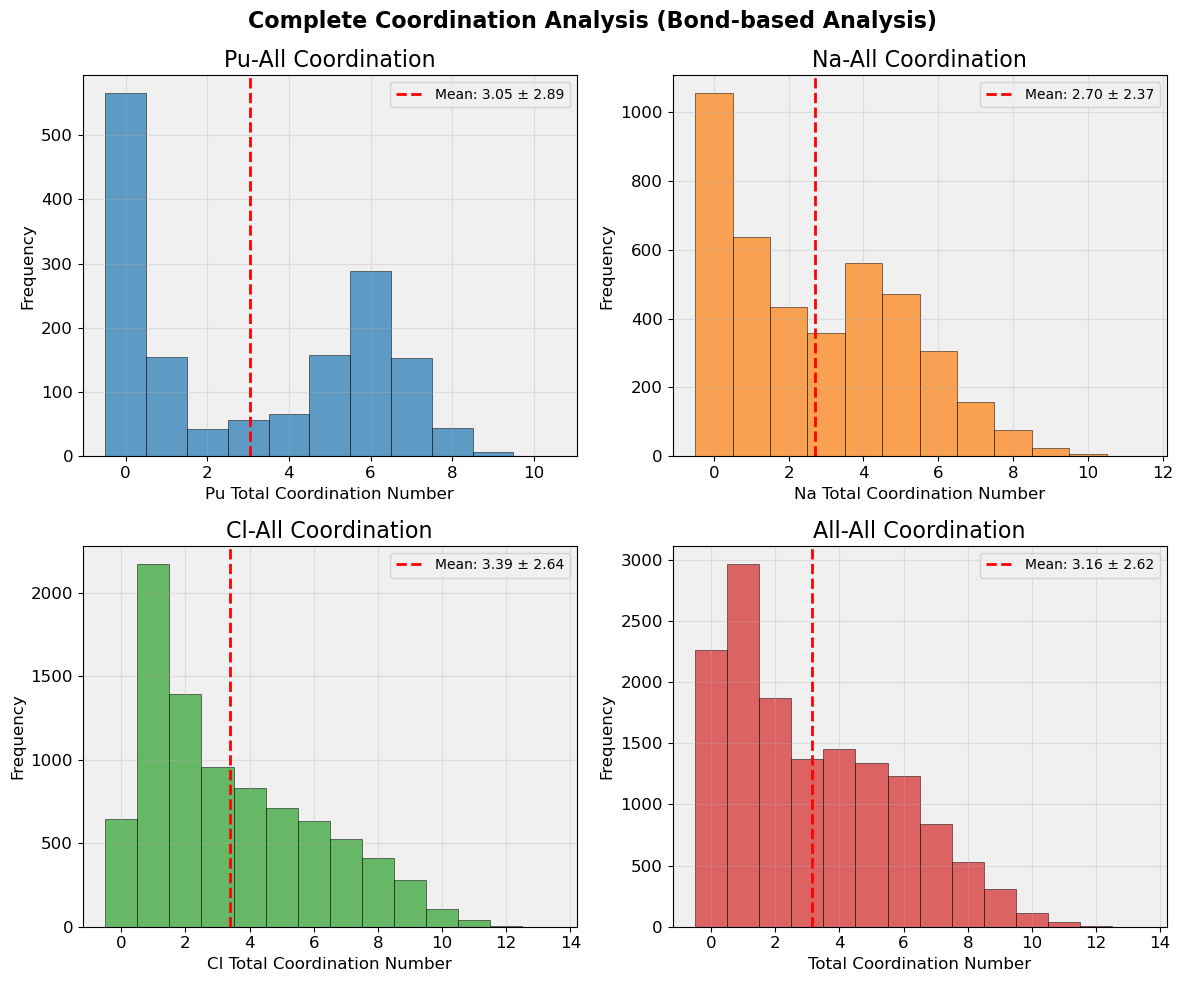


COMPLETE COORDINATION PANEL ANALYSIS COMPLETE


PLOTTING ANY-SPECIES COORDINATION HISTOGRAMS
Any-Pu: 0.65 ± 0.65 (n=3584)
Any-Na: 1.54 ± 1.10 (n=3584)
Any-Cl: 4.12 ± 1.47 (n=3584)


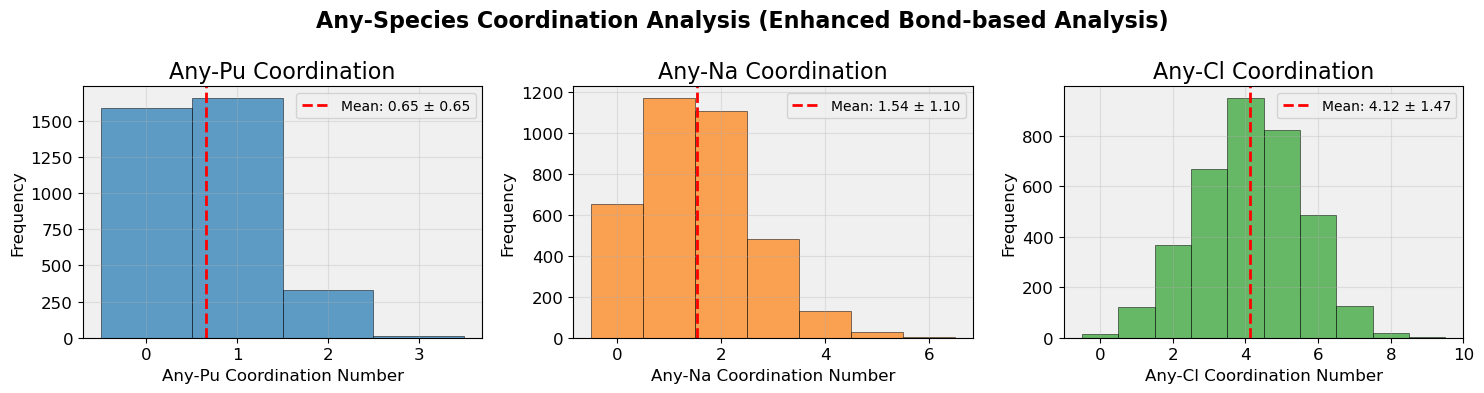


ANY-SPECIES COORDINATION PLOTTING COMPLETE


In [25]:
# Plot any-species coordination histograms (any central species to specific neighbor species)
print("=" * 60)
print("PLOTTING ANY-SPECIES COORDINATION HISTOGRAMS")
print("=" * 60)

def plot_any_species_coordination_histograms(coord_data, title_suffix=""):
    """
    Plot histograms for any-species coordination (any central species to specific neighbor species).
    
    Parameters:
        coord_data: Enhanced coordination data with 'any' structures
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Check if 'any' coordination data exists
    if 'any' not in coord_data:
        print("No 'any' coordination data found")
        return
    
    # Get available neighbor species
    neighbor_species = []
    for sp in ['Pu', 'Na', 'Cl']:
        if sp in coord_data['any'] and coord_data['any'][sp]:
            neighbor_species.append(sp)
    
    if not neighbor_species:
        print("No any-species coordination data available")
        return
    
    # Create subplots
    n_neighbors = len(neighbor_species)
    fig, axes = plt.subplots(1, n_neighbors, figsize=(5*n_neighbors, 4))
    if n_neighbors == 1:
        axes = [axes]
    
    fig.suptitle(f'Any-Species Coordination Analysis{title_suffix}', fontsize=16, fontweight='bold')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, neighbor_sp in enumerate(neighbor_species):
        counts = coord_data['any'][neighbor_sp]
        
        if not counts:
            continue
            
        # Create histogram
        max_coord = max(counts) if counts else 0
        bins = np.arange(0, max_coord + 2) - 0.5
        
        axes[idx].hist(counts, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                      edgecolor='black', linewidth=0.5)
        
        # Add statistics
        mean_coord = np.mean(counts)
        std_coord = np.std(counts)
        axes[idx].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
        
        axes[idx].set_xlabel(f'Any-{neighbor_sp} Coordination Number')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'Any-{neighbor_sp} Coordination')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # Print statistics
        print(f'Any-{neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
    
    plt.tight_layout()
    plt.show()

# Plot any-species coordination histograms
plot_any_species_coordination_histograms(coord_data_enhanced, " (Enhanced Bond-based Analysis)")

print("\n" + "=" * 60)
print("ANY-SPECIES COORDINATION PLOTTING COMPLETE")
print("=" * 60)


COMPREHENSIVE COORDINATION ANALYSIS PANEL
Pu-Any: 6.10 ± 1.38 (n=384)
Na-Any: 5.40 ± 1.73 (n=1024)
Cl-Any: 6.79 ± 1.98 (n=2176)
Any-Pu: 0.65 ± 0.65 (n=3584)
Any-Na: 1.54 ± 1.10 (n=3584)
Any-Cl: 4.12 ± 1.47 (n=3584)
Any-Any: 6.32 ± 1.95 (n=3584)


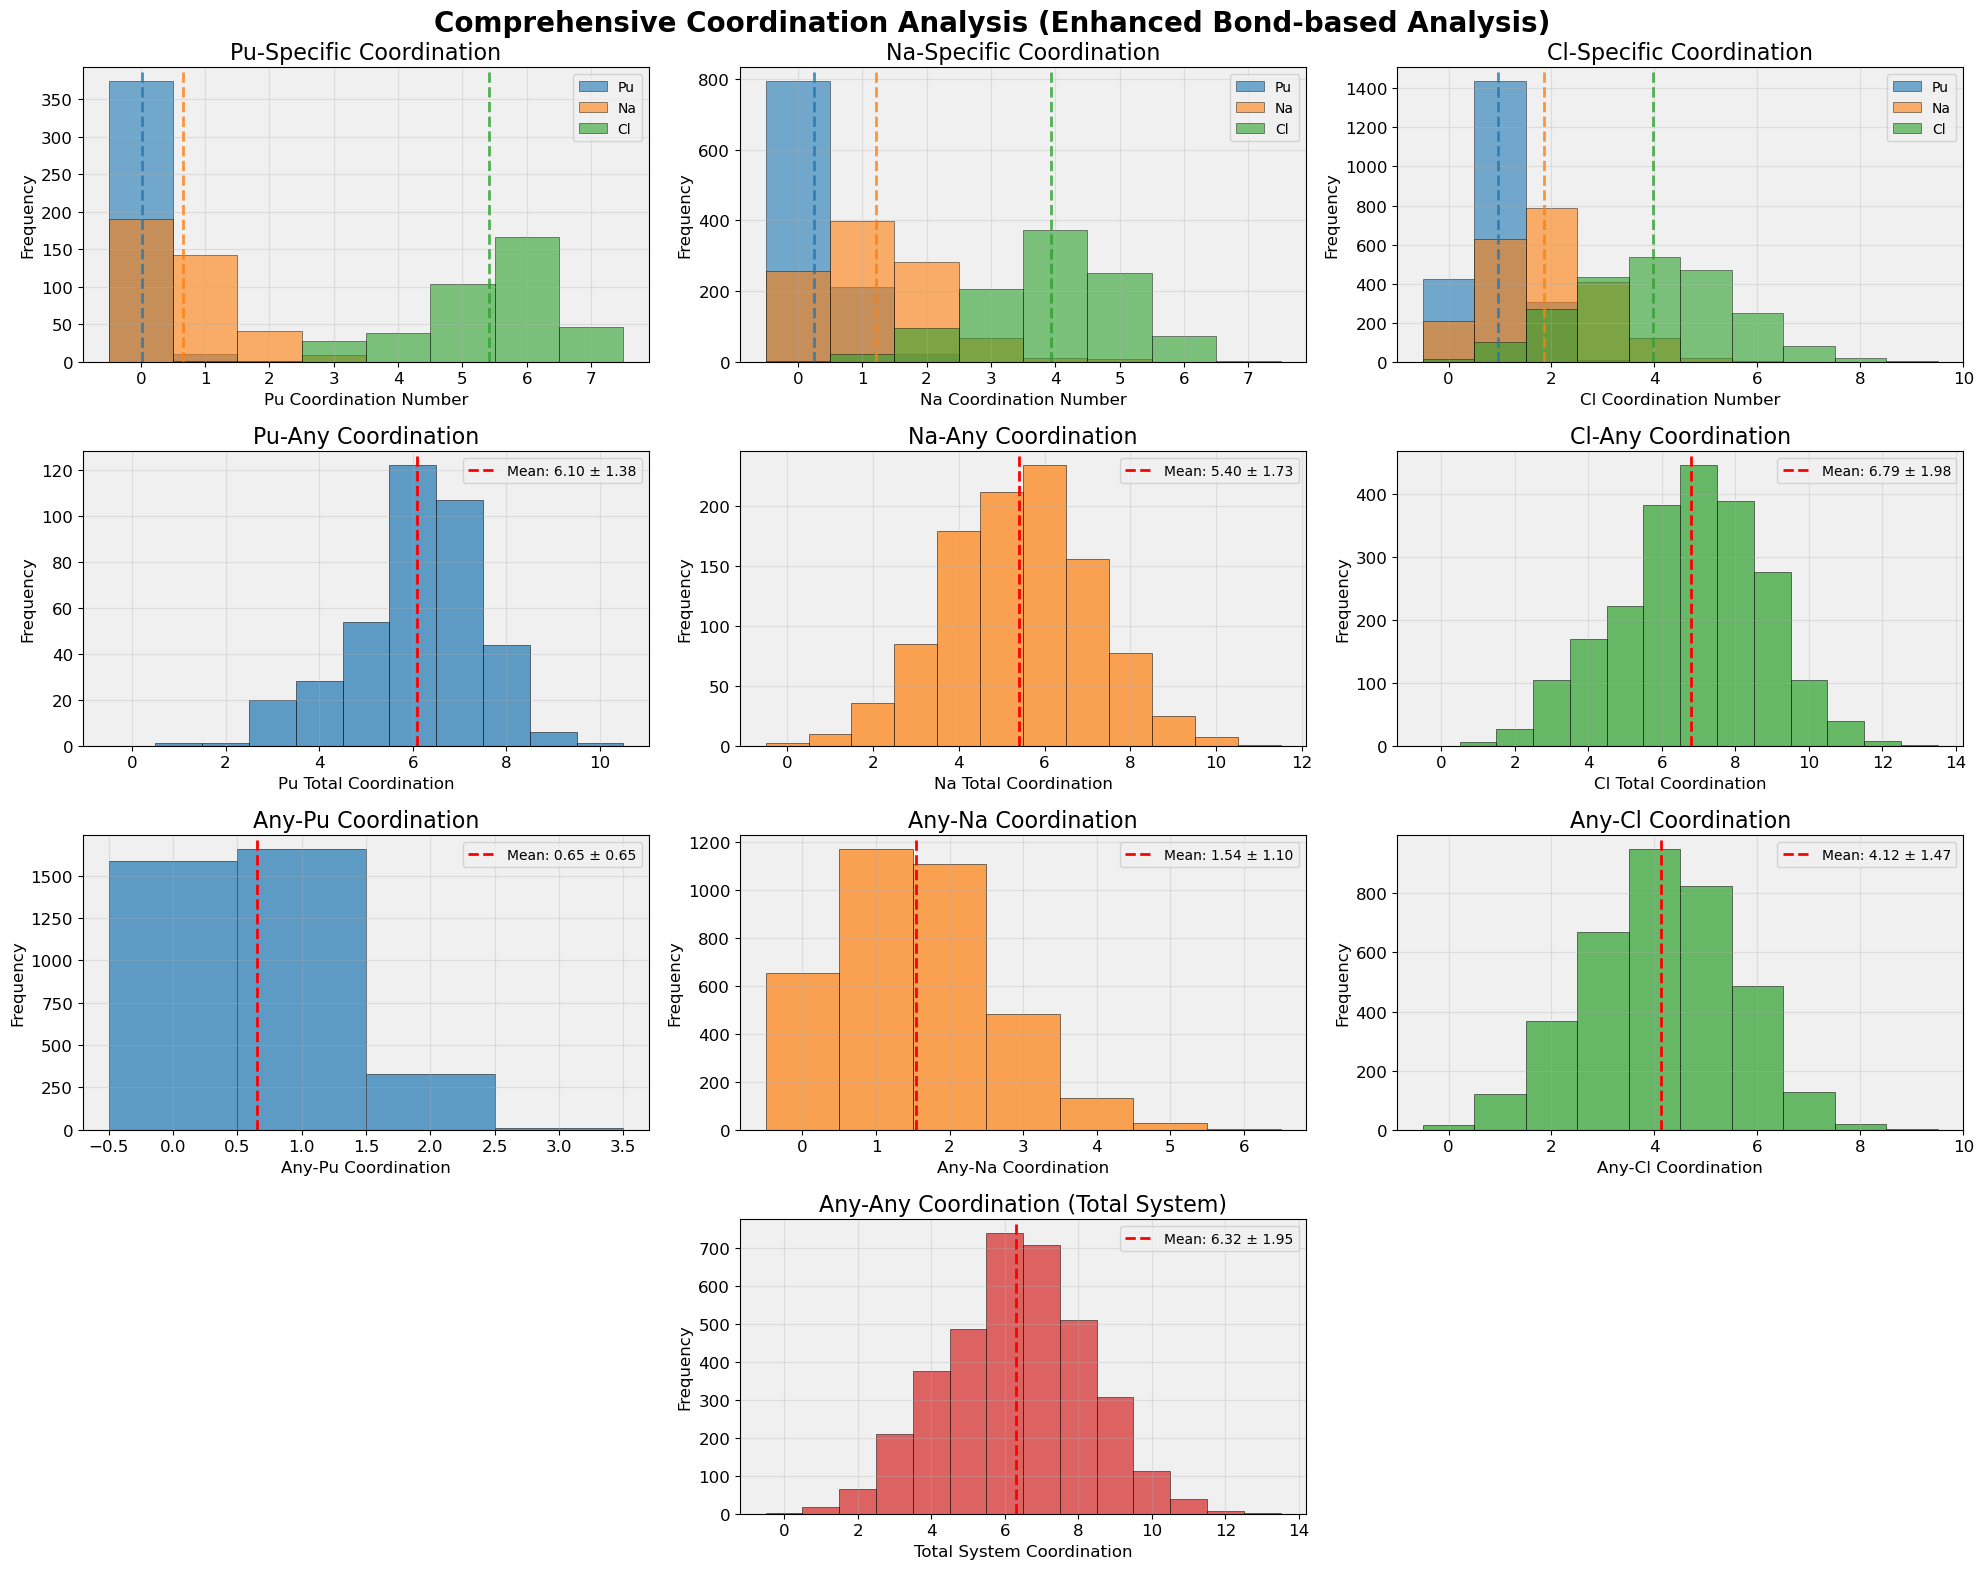


COMPREHENSIVE COORDINATION ANALYSIS COMPLETE


In [26]:
# Comprehensive coordination analysis panel showing all coordination types
print("=" * 60)
print("COMPREHENSIVE COORDINATION ANALYSIS PANEL")
print("=" * 60)

def plot_comprehensive_coordination_panel(coord_data, title_suffix=""):
    """
    Create a comprehensive coordination panel showing all coordination types:
    - Species-specific coordination (Pu-Pu, Pu-Na, Pu-Cl, etc.)
    - Species-any coordination (Pu-any, Na-any, Cl-any)
    - Any-species coordination (any-Pu, any-Na, any-Cl)
    - Any-any coordination (total system coordination)
    
    Parameters:
        coord_data: Enhanced coordination data with all structures
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    # Create a large subplot layout
    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(f'Comprehensive Coordination Analysis{title_suffix}', fontsize=20, fontweight='bold')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']
    
    # Define species
    species = ['Pu', 'Na', 'Cl']
    
    # Plot 1: Species-specific coordination (top row)
    for i, central_sp in enumerate(species):
        if central_sp in coord_data:
            ax = plt.subplot(4, 3, i + 1)
            
            # Get coordination data for this central species
            species_data = coord_data[central_sp]
            neighbor_species = [sp for sp in species if sp in species_data and species_data[sp]]
            
            if neighbor_species:
                # Plot histograms for each neighbor species
                for j, neighbor_sp in enumerate(neighbor_species):
                    counts = species_data[neighbor_sp]
                    if counts:
                        max_coord = max(counts)
                        bins = np.arange(0, max_coord + 2) - 0.5
                        
                        ax.hist(counts, bins=bins, alpha=0.6, color=colors[j % len(colors)], 
                               edgecolor='black', linewidth=0.5, label=f'{neighbor_sp}')
                        
                        mean_coord = np.mean(counts)
                        ax.axvline(mean_coord, color=colors[j % len(colors)], linestyle='--', 
                                 linewidth=2, alpha=0.8)
                
                ax.set_xlabel(f'{central_sp} Coordination Number')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{central_sp}-Specific Coordination')
                ax.legend()
                ax.grid(True, alpha=0.3)
            else:
                ax.text(0.5, 0.5, f'No {central_sp} coordination data', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_title(f'{central_sp}-Specific Coordination')
    
    # Plot 2: Species-any coordination (second row)
    for i, central_sp in enumerate(species):
        ax = plt.subplot(4, 3, i + 4)
        
        if central_sp in coord_data and 'any' in coord_data[central_sp]:
            counts = coord_data[central_sp]['any']
            if counts:
                max_coord = max(counts)
                bins = np.arange(0, max_coord + 2) - 0.5
                
                ax.hist(counts, bins=bins, alpha=0.7, color=colors[i % len(colors)], 
                       edgecolor='black', linewidth=0.5)
                
                mean_coord = np.mean(counts)
                std_coord = np.std(counts)
                ax.axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
                
                ax.set_xlabel(f'{central_sp} Total Coordination')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{central_sp}-Any Coordination')
                ax.legend()
                ax.grid(True, alpha=0.3)
                
                print(f'{central_sp}-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
        else:
            ax.text(0.5, 0.5, f'No {central_sp}-any data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{central_sp}-Any Coordination')
    
    # Plot 3: Any-species coordination (third row)
    for i, neighbor_sp in enumerate(species):
        ax = plt.subplot(4, 3, i + 7)
        
        if 'any' in coord_data and neighbor_sp in coord_data['any']:
            counts = coord_data['any'][neighbor_sp]
            if counts:
                max_coord = max(counts)
                bins = np.arange(0, max_coord + 2) - 0.5
                
                ax.hist(counts, bins=bins, alpha=0.7, color=colors[i % len(colors)], 
                       edgecolor='black', linewidth=0.5)
                
                mean_coord = np.mean(counts)
                std_coord = np.std(counts)
                ax.axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
                
                ax.set_xlabel(f'Any-{neighbor_sp} Coordination')
                ax.set_ylabel('Frequency')
                ax.set_title(f'Any-{neighbor_sp} Coordination')
                ax.legend()
                ax.grid(True, alpha=0.3)
                
                print(f'Any-{neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
        else:
            ax.text(0.5, 0.5, f'No any-{neighbor_sp} data', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'Any-{neighbor_sp} Coordination')
    
    # Plot 4: Any-any coordination (bottom row, centered)
    ax = plt.subplot(4, 3, 11)
    
    if 'any' in coord_data and 'any' in coord_data['any']:
        counts = coord_data['any']['any']
        if counts:
            max_coord = max(counts)
            bins = np.arange(0, max_coord + 2) - 0.5
            
            ax.hist(counts, bins=bins, alpha=0.7, color=colors[3 % len(colors)], 
                   edgecolor='black', linewidth=0.5)
            
            mean_coord = np.mean(counts)
            std_coord = np.std(counts)
            ax.axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                     label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
            
            ax.set_xlabel('Total System Coordination')
            ax.set_ylabel('Frequency')
            ax.set_title('Any-Any Coordination (Total System)')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            print(f'Any-Any: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
    else:
        ax.text(0.5, 0.5, 'No any-any data', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title('Any-Any Coordination')
    
    # Hide the unused subplot
    ax = plt.subplot(4, 3, 12)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Create the comprehensive coordination panel
plot_comprehensive_coordination_panel(coord_data_enhanced, " (Enhanced Bond-based Analysis)")

print("\n" + "=" * 60)
print("COMPREHENSIVE COORDINATION ANALYSIS COMPLETE")
print("=" * 60)
